## 1. Imports

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath(".."))

# EarlyFusion models
from EarlyFusion.EarlyFusionMLP import *
from EarlyFusion.EarlyFusionCNN import *
from EarlyFusion.utils import cross_validation_5fold_early_fusion

## 2. Data Loading

In [ ]:
AUDIO_FEATURES = "/mloscratch/users/gnahas/data/features/acoustic_features_vf.csv"
TAPPING_FEATURES = "/mloscratch/users/clerget/data/csv/tapping_combined_features_session.csv"
LABELS = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/paired_healthcode.csv"
TRAIN_FOLDS = "/mloscratch/users/gnahas/data/data_paired/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_train.csv"
VAL_TEST_FOLDS = "/mloscratch/users/gnahas/data/data_paired/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_val_test.csv"

## 3. Concatenation

In [ ]:
audio_features = pd.read_csv(AUDIO_FEATURES)
tapping_features = pd.read_csv(TAPPING_FEATURES)

# Rename 'healthcode' to 'healthCode' for consistency if needed
if 'healthcode' in audio_features.columns and 'healthCode' not in audio_features.columns:
    audio_features = audio_features.rename(columns={'healthcode': 'healthCode'})

if 'healthcode' in tapping_features.columns and 'healthCode' not in TAPPING_FEATURES.columns:
    tapping_features = tapping_features.rename(columns={'healthcode': 'healthCode'})

# Count occurrences of trials per patient in each dataframe
counts_audio = audio_features["healthCode"].value_counts()
counts_tapping = tapping_features["healthCode"].value_counts()

# Consider healthCodes present in both files
shared_healthCodes = counts_audio.index.intersection(counts_tapping.index)

# Helper: minimum count of trials for each patient
min_counts = {code: min(counts_audio[code], counts_tapping[code]) for code in shared_healthCodes}

# Dropping extra audio trials per patient where needed
counts_audio_balanced = (
    audio_features[audio_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

# Dropping extra tapping trials per patient where needed
counts_tapping_balanced = (
    tapping_features[tapping_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

counts_audio_balanced["row_id"] = counts_audio_balanced.groupby("healthCode").cumcount()
counts_tapping_balanced["row_id"] = counts_tapping_balanced.groupby("healthCode").cumcount()

features_merged = pd.merge(
    counts_audio_balanced,
    counts_tapping_balanced,
    on=["healthCode", "row_id"],
    suffixes=("_file1", "_file2")
)

features_merged.to_csv("/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/fusion_features.csv", index=False)


AttributeError: 'str' object has no attribute 'columns'

In [ ]:
FUSION_FEATURES = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/fusion_features.csv"

## 4. Cross-Validation

In [3]:
# Load the data files
features_df = pd.read_csv(AUDIO_FEATURES)
labels_df = pd.read_csv(LABELS)
train_folds_df = pd.read_csv(TRAIN_FOLDS)
val_test_folds_df = pd.read_csv(VAL_TEST_FOLDS)

print(f"Loaded features: {features_df.shape}")
print(f"  Columns: {list(features_df.columns[:5])}...")

print(f"Loaded labels: {labels_df.shape}")
print(f"  Columns: {list(labels_df.columns)}")

print(f"Train folds: {train_folds_df.shape}")
print(f"  Columns: {list(train_folds_df.columns)}")
print(f"Val+Test folds: {val_test_folds_df.shape}")
print(f"  Columns: {list(val_test_folds_df.columns)}")

# Separate val and test based on 'subset' column
val_folds_df = val_test_folds_df[val_test_folds_df['subset'] == 'val']
test_folds_df = val_test_folds_df[val_test_folds_df['subset'] == 'test']
print(f"  - Validation folds: {val_folds_df.shape}")
print(f"  - Test folds: {test_folds_df.shape}")

if 'healthcode' in features_df.columns and 'healthCode' not in features_df.columns:
        features_df = features_df.rename(columns={'healthcode': 'healthCode'})
        print(f"Renamed 'healthcode' → 'healthCode' for consistency")

# Merge features with labels on healthCode
features_df = features_df.merge(labels_df[['healthCode', 'label_PD']], on='healthCode', how='inner')
print(f"Features after merging with labels: {features_df.shape}")

# Filter to only include healthcodes in 5-fold splits
all_fold_healthcodes = set(train_folds_df['healthCode'].unique()) | set(val_test_folds_df['healthCode'].unique())
features_df = features_df[features_df['healthCode'].isin(all_fold_healthcodes)]
print(f"Features after filtering to 5-fold healthcodes: {features_df.shape}")

# Prepare feature columns (exclude metadata)
# After renaming: 'healthcode' → 'healthCode', so only 'healthCode' exists
metadata_cols = ['filename', 'healthCode', 'record_id', 'label_PD']
feature_cols = [col for col in features_df.columns if col not in metadata_cols]
print(f"Number of features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols[:5]}... (showing first 5)")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

# Get unique patient healthCodes for fold 0 (for filtering)
train_patient_ids = train_folds_df[train_folds_df['fold_iteration'] == 0]['healthCode'].values
val_patient_ids = val_folds_df[val_folds_df['fold_iteration'] == 0]['healthCode'].values
test_patient_ids = test_folds_df[test_folds_df['fold_iteration'] == 0]['healthCode'].values

print(f"Train patients: {len(train_patient_ids)}")
print(f"Val patients: {len(val_patient_ids)}")
print(f"Test patients: {len(test_patient_ids)}")

# Split data by patient healthCode
train_data = features_df[features_df['healthCode'].isin(train_patient_ids)]
val_data = features_df[features_df['healthCode'].isin(val_patient_ids)]
test_data = features_df[features_df['healthCode'].isin(test_patient_ids)]

print(f"Train samples (before undersampling): {len(train_data)}")
print(f"Val samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

# Extract features and labels
X_train = train_data[feature_cols].values.astype(np.float32)
y_train = train_data['label_PD'].values
X_val = val_data[feature_cols].values.astype(np.float32)
y_val = val_data['label_PD'].values
X_test = test_data[feature_cols].values.astype(np.float32)
y_test = test_data['label_PD'].values

# Handle NaN values
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val = np.nan_to_num(X_val, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

# Normalize features using StandardScaler (fit on train, transform on val/test)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Initialize model
model = EarlyFusionMLP(
    input_dim=X_train.shape[1],
    hidden_dims=[256, 128, 64],
    dropout=0.3,
    verbose=True
)

# Train model
print("\n" + "="*50)
print("Training EarlyFusionMLP...")
print("="*50)
model.fit(
    X_train_tensor, 
    y_train_tensor,
    val_features=X_val_tensor,
    val_labels=y_val_tensor,
    epochs=100,
    class_weight = 3,
    batch_size=64,
    lr=0.001,
    weight_decay=0.01,
    verbose=True
)

# Test model with majority voting per patient
print("\n" + "="*50)
print("Testing EarlyFusionMLP with Majority Voting...")
print("="*50)

# Prepare test dataframe with standardized features
test_data_standardized = test_data.copy()
test_data_standardized[feature_cols] = X_test

# Use the test_with_majority_counting method
test_results = model.test_with_majority_counting(test_data_standardized)

# Display results
print(f"\nPatient-level Results (Majority Voting):")
print(f"  Number of patients: {test_results['num_patients']}")
print(f"  Number of trials: {test_results['num_trials']}")
print(f"  Test Accuracy: {test_results['test_acc']:.4f}")
print(f"  Test F1 Score: {test_results['test_f1']:.4f}")
print(f"  Test ROC AUC: {test_results['test_roc_auc']:.4f}")
print(f"\nConfusion Matrix:\n{test_results['test_conf_mat']}")

Loaded features: (14948, 157)
  Columns: ['filename', 'healthcode', 'record_id', 'mfcc_1_mean', 'mfcc_1_std']...
Loaded labels: (532, 3)
  Columns: ['healthCode', 'label_PD', 'modality']
Train folds: (1380, 3)
  Columns: ['fold_iteration', 'healthCode', 'subset']
Val+Test folds: (1064, 3)
  Columns: ['fold_iteration', 'healthCode', 'subset']
  - Validation folds: (532, 3)
  - Test folds: (532, 3)
Renamed 'healthcode' → 'healthCode' for consistency
Features after merging with labels: (14944, 158)
Features after filtering to 5-fold healthcodes: (14944, 158)
Number of features: 154
Feature columns: ['mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean']... (showing first 5)
Using device: cuda

Train patients: 276
Val patients: 107
Test patients: 107
Train samples (before undersampling): 7198
Val samples: 3448
Test samples: 2284
Input dimension: 154
MLP architecture: 154 -> 256 -> 128 -> 64 -> 2 (binary classification)
Device: cuda

Training EarlyFusionMLP...


/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/EarlyFusion/EarlyFusionMLP.py:158: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Scalar.cpp:22.)
  epoch_loss += loss.item() * len(lbl)


Epoch 10/100 | Train Loss: 0.2459 | Train Acc: 0.8990 | Val Loss: 0.9390 | Val Acc: 0.6015 | LR: 0.001000
Learning rate reduced to 0.000500
Epoch 20/100 | Train Loss: 0.1592 | Train Acc: 0.9418 | Val Loss: 1.1152 | Val Acc: 0.6325 | LR: 0.000500
Learning rate reduced to 0.000250
Early stopping triggered at epoch 21. No improvement for 20 epochs.
Training complete. Final - Loss: 0.1497, Acc: 0.9453

Testing EarlyFusionMLP with Majority Voting...

Patient-level Results (Majority Voting):
  Number of patients: 107
  Number of trials: 2284
  Test Accuracy: 0.6168
  Test F1 Score: 0.6612
  Test ROC AUC: 0.6126

Confusion Matrix:
[[26 20]
 [21 40]]


In [ ]:
output_dir_mlp = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/models/EarlyFusion/"

print("Running 5-fold CV with EarlyFusionMLP on Extracted Features...")
cv_results = cross_validation_5fold_early_fusion(
    features_csv=FUSION_FEATURES,
    labels_csv=LABELS,
    train_folds_csv=TRAIN_FOLDS,
    val_test_folds_csv=VAL_TEST_FOLDS,
    output_dir=output_dir_mlp,
    hidden_dims=[256, 128, 64],
    batch_size=64,
    num_epochs=150,
    learning_rate=0.001,
    weight_decay=0.01,
    dropout=0.8,
    class_weight=3.5,
    verbose=True
)

print(f"\nModels saved at: {cv_results['model_paths']}")

Running 5-fold CV with EarlyFusionMLP on Extracted Features...
Loaded features: (14948, 157)
  Columns: ['filename', 'healthcode', 'record_id', 'mfcc_1_mean', 'mfcc_1_std']...
Loaded labels: (532, 3)
  Columns: ['healthCode', 'label_PD', 'modality']
Train folds: (1380, 3)
  Columns: ['fold_iteration', 'healthCode', 'subset']
Val+Test folds: (1064, 3)
  Columns: ['fold_iteration', 'healthCode', 'subset']
  - Validation folds: (532, 3)
  - Test folds: (532, 3)
Renamed 'healthcode' → 'healthCode' for consistency
Features after merging with labels: (14944, 158)
Features after filtering to 5-fold healthcodes: (14944, 158)
Number of features: 154
Feature columns: ['mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean']... (showing first 5)
Using device: cuda


Fold 0/4 (Fold iteration 0)
Train patients: 276
Val patients: 107
Test patients: 107
Train samples: 7198
Val samples: 3448
Test samples: 2284
Loaded features: (14948, 157)
  Columns: ['filename', 'healthcode', 'record_

/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/EarlyFusion/EarlyFusionMLP.py:158: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Scalar.cpp:22.)
  epoch_loss += loss.item() * len(lbl)


Epoch 10/150 | Train Loss: 0.4763 | Train Acc: 0.7684 | Val Loss: 0.6811 | Val Acc: 0.4838 | Val AUC: 0.6838 | LR: 0.001000
Learning rate reduced to 0.000500
Learning rate reduced to 0.000500
Epoch 20/150 | Train Loss: 0.4308 | Train Acc: 0.8159 | Val Loss: 0.7081 | Val Acc: 0.5658 | Val AUC: 0.6647 | LR: 0.000500
Epoch 20/150 | Train Loss: 0.4308 | Train Acc: 0.8159 | Val Loss: 0.7081 | Val Acc: 0.5658 | Val AUC: 0.6647 | LR: 0.000500
Learning rate reduced to 0.000250
Learning rate reduced to 0.000250
Epoch 30/150 | Train Loss: 0.3699 | Train Acc: 0.8443 | Val Loss: 0.7663 | Val Acc: 0.6157 | Val AUC: 0.6411 | LR: 0.000250
Epoch 30/150 | Train Loss: 0.3699 | Train Acc: 0.8443 | Val Loss: 0.7663 | Val Acc: 0.6157 | Val AUC: 0.6411 | LR: 0.000250
Learning rate reduced to 0.000125
Learning rate reduced to 0.000125
Epoch 40/150 | Train Loss: 0.3191 | Train Acc: 0.8722 | Val Loss: 0.8286 | Val Acc: 0.6090 | Val AUC: 0.6347 | LR: 0.000125
Epoch 40/150 | Train Loss: 0.3191 | Train Acc: 0.872

## 5. Results Visualization

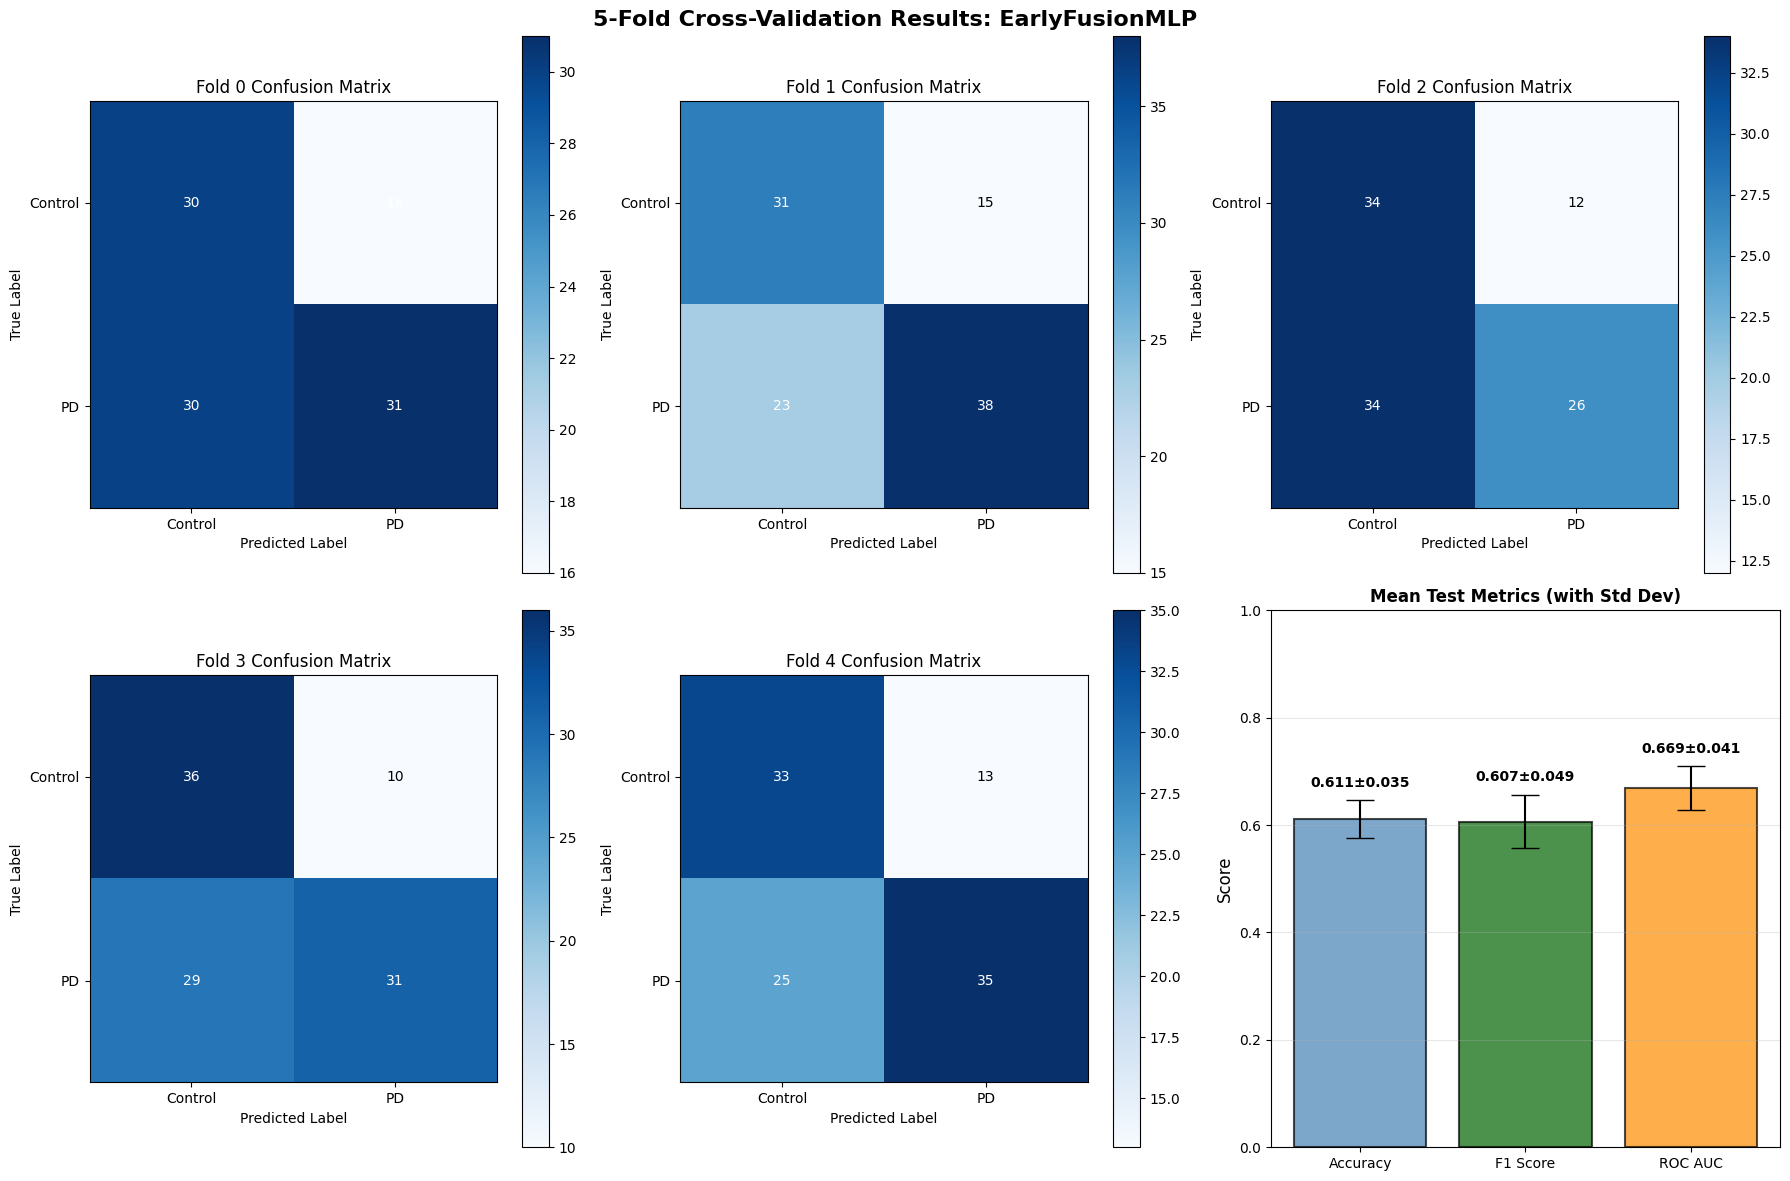


Summary Statistics:
Test Accuracy: 0.6109 ± 0.0353
Test F1 Score: 0.6067 ± 0.0494
Test ROC AUC:  0.6686 ± 0.0408


In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('5-Fold Cross-Validation Results: EarlyFusionMLP', fontsize=16, fontweight='bold')

# Plot confusion matrices for each fold
for i, cm in enumerate(cv_results['confusion_matrices']):
    if i < 5:  # We have 5 folds
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        
        # Plot confusion matrix as heatmap
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(f'Fold {i} Confusion Matrix')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        
        # Add colorbar
        plt.colorbar(im, ax=ax)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for row_idx in range(cm.shape[0]):
            for col_idx in range(cm.shape[1]):
                ax.text(col_idx, row_idx, format(cm[row_idx, col_idx], 'd'),
                       ha="center", va="center",
                       color="white" if cm[row_idx, col_idx] > thresh else "black")
        
        # Set ticks
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Control', 'PD'])
        ax.set_yticklabels(['Control', 'PD'])

# Plot mean metrics with error bars in the last subplot
ax = axes[1, 2]
metrics = ['Accuracy', 'F1 Score', 'ROC AUC']
means = [cv_results['mean_test_acc'], cv_results['mean_test_f1'], cv_results['mean_test_roc_auc']]
stds = [cv_results['std_test_acc'], cv_results['std_test_f1'], cv_results['std_test_roc_auc']]

x_pos = np.arange(len(metrics))
bars = ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.7, 
              color=['steelblue', 'darkgreen', 'darkorange'], 
              ecolor='black', capsize=10, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Mean Test Metrics (with Std Dev)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Test Accuracy: {cv_results['mean_test_acc']:.4f} ± {cv_results['std_test_acc']:.4f}")
print(f"Test F1 Score: {cv_results['mean_test_f1']:.4f} ± {cv_results['std_test_f1']:.4f}")
print(f"Test ROC AUC:  {cv_results['mean_test_roc_auc']:.4f} ± {cv_results['std_test_roc_auc']:.4f}")